# AS Simplified

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# --- Part 1: Consolidate All AoV Data Sources ---
# This section combines the logic from our previous steps to create a single,
# clean DataFrame with 'normal', 'mild', 'moderate', and 'severe' labels.

# Recreate all four DataFrames based on the provided images
as_normal_obs_data = {'Value': ['normal'] * 13771 + ['AoV_Normal'] * 1188}
as_obs_data = {
    'Value': ['Sclerosis_mild'] * 6289 + ['AS_severe'] * 1977 + 
             ['AS_mild'] * 1662 + ['AS_moderate'] * 1258 +
             ['Mild_to_mod_sclerosis'] * 1189 + ['AS_mod_to_severe'] * 597 +
             ['AS_mild_to_moderate'] * 460
}
as_normal_obs = pd.DataFrame(as_normal_obs_data)
as_obs = pd.DataFrame(as_obs_data)

asten2_obs_data = {
    'Value': ['none'] * 1819 + ['severe'] * 1037 + ['moderate_to_severe'] * 229 +
             ['moderate'] * 208 + ['mild'] * 137 + ['mild_to_moderate'] * 44 +
             ['No_neoaortic_stenosis'] * 1
}
asten_obs_data = {
    'Value': ['mild'] * 30534 + ['none'] * 7549 + ['moderate'] * 3639 +
             ['severe'] * 2180
}
asten2_obs = pd.DataFrame(asten2_obs_data)
asten_obs = pd.DataFrame(asten_obs_data)

# Combine all four DataFrames
all_aov_obs = pd.concat([as_normal_obs, as_obs, asten2_obs, asten_obs], ignore_index=True)

# Define a comprehensive mapping for all categories
replacement_map = {
    'normal': 'normal', 'none': 'normal', 'AoV_Normal': 'normal', 'No_neoaortic_stenosis': 'normal',
    'mild': 'mild', 'AS_mild': 'mild',
    'moderate': 'moderate', 'mild_to_moderate': 'moderate', 'AS_mild_to_moderate': 'moderate', 'AS_moderate': 'moderate',
    'severe': 'severe', 'moderate_to_severe': 'severe', 'AS_mod_to_severe': 'severe', 'AS_severe': 'severe'
}

# Filter and apply the mapping to get the clean, consolidated labels
aov_labels = all_aov_obs[all_aov_obs['Value'].isin(replacement_map.keys())].copy()
aov_labels['Value'] = aov_labels['Value'].replace(replacement_map)

# Add a placeholder 'URI' column since it's needed for the output files
aov_labels['URI'] = [f'aov_video_{i}.mp4' for i in range(len(aov_labels))]

# Rename for consistency with the original script structure
df = aov_labels


# --- Part 2: Create Binary Labels and Split Data ---
# This section adapts your script to work with the consolidated AoV data.

# Define the size of the small subset for the overfitting test
SUBSET_SIZE = 1000

# --- 1. Create a binary label (0 for 'normal', 1 for 'stenosis') ---
# All labels that are not 'normal' (i.e., mild, moderate, severe) are mapped to 1.
df['binary_label'] = (df['Value'] != 'normal').astype(int)

# --- 2. Create a small, stratified subset for overfitting ---
# This ensures the proportion of normal/stenosis is similar to the full dataset.
small_df, _ = train_test_split(
    df,
    train_size=SUBSET_SIZE,
    stratify=df['binary_label'], # Keep class balance
    random_state=42
)

# --- 3. Split the SMALL subset into train, validation, and test (64/16/20) ---
# First split: 80% for train/val, 20% for test
train_val_df, test_df = train_test_split(
    small_df,
    test_size=0.2,
    stratify=small_df['binary_label'],
    random_state=42
)

# Second split: 80% of the remainder for train, 20% for validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2, # 0.2 * 0.8 = 0.16 (16% of the small subset)
    stratify=train_val_df['binary_label'],
    random_state=42
)

# --- 4. Save files and print statistics ---
# Save the files with URI and the new binary label
train_df[['URI', 'binary_label']].to_csv('aov_binary_train.csv', header=False, index=False, sep=' ')
val_df[['URI', 'binary_label']].to_csv('aov_binary_val.csv', header=False, index=False, sep=' ')
test_df[['URI', 'binary_label']].to_csv('aov_binary_test.csv', header=False, index=False, sep=' ')

# Print split statistics
print(f"Total samples in subset: {len(small_df)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(small_df)*100:.1f}%) -> {len(train_df)} samples")
print(f"Validation: {len(val_df)} ({len(val_df)/len(small_df)*100:.1f}%) -> {len(val_df)} samples")
print(f"Test: {len(test_df)} ({len(test_df)/len(small_df)*100:.1f}%) -> {len(test_df)} samples")

# Print label distribution for each new split
print("\nBinary Label Distribution (0: normal, 1: stenosis):")
binary_label_meaning = {0: 'normal', 1: 'stenosis'}
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{split_name}:")
    # Use value_counts() and sort_index() for a clean report
    for label, count in split_df['binary_label'].value_counts().sort_index().items():
        print(f"  {label} ({binary_label_meaning[label]}): {count}")


Total samples in subset: 1000
Train: 640 (64.0%) -> 640 samples
Validation: 160 (16.0%) -> 160 samples
Test: 200 (20.0%) -> 200 samples

Binary Label Distribution (0: normal, 1: stenosis):
Train:
  0 (normal): 228
  1 (stenosis): 412
Val:
  0 (normal): 57
  1 (stenosis): 103
Test:
  0 (normal): 71
  1 (stenosis): 129


# Pacemaker Simplified

# MVR Simplified

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define the size of the small subset for the overfitting test
SUBSET_SIZE = 1000

# Read the original full dataset
df = pd.read_csv('a4c_mvr_labels.csv')

# --- 1. Create a binary label (0 for 'trace', 1 for 'non-trace') ---
# All labels that are not 'trace' will be mapped to 1.
df['binary_label'] = (df['Value'] != 'trace').astype(int)

# --- 2. Create a small, stratified subset for overfitting ---
# This ensures the proportion of trace/non-trace is similar to the full dataset.
# We use train_test_split to sample, discarding the larger part.
small_df, _ = train_test_split(
    df,
    train_size=SUBSET_SIZE,
    stratify=df['binary_label'], # Keep class balance
    random_state=42
)

# --- 3. Split the SMALL subset into train, validation, and test (64/16/20) ---
# First split: 80% for train/val, 20% for test
train_val_df, test_df = train_test_split(
    small_df,
    test_size=0.2,
    stratify=small_df['binary_label'],
    random_state=42
)

# Second split: 80% of the remainder for train, 20% for validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2, # 0.2 * 0.8 = 0.16 (16% of the small subset)
    stratify=train_val_df['binary_label'],
    random_state=42
)

# --- 4. Save files and print statistics ---
# Save the files with URI and the new binary label
train_df[['URI', 'binary_label']].to_csv('a4c_binary_train.csv', header=False, index=False, sep=' ')
val_df[['URI', 'binary_label']].to_csv('a4c_binary_val.csv', header=False, index=False, sep=' ')
test_df[['URI', 'binary_label']].to_csv('a4c_binary_test.csv', header=False, index=False, sep=' ')

# Print split statistics
print(f"Total samples in subset: {len(small_df)}")
print(f"Train: {len(train_df)} ({len(train_df)/len(small_df)*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(small_df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(small_df)*100:.1f}%)")

# Print label distribution for each new split
print("\nBinary Label Distribution (0: trace, 1: non-trace):")
binary_label_meaning = {0: 'trace', 1: 'non-trace'}
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{split_name}:")
    # Use value_counts() and sort_index() for a clean report
    for label, count in split_df['binary_label'].value_counts().sort_index().items():
        print(f"  {label} ({binary_label_meaning[label]}): {count}")

Total samples in subset: 1000
Train: 640 (64.0%)
Validation: 160 (16.0%)
Test: 200 (20.0%)

Binary Label Distribution (0: trace, 1: non-trace):
Train:
  0 (trace): 390
  1 (non-trace): 250
Val:
  0 (trace): 97
  1 (non-trace): 63
Test:
  0 (trace): 122
  1 (non-trace): 78


# Pacemaker

# A4C

In [1]:
import pandas as pd
from pathlib import Path

all_es = pd.read_parquet('all_es_combined.parquet')

In [2]:
# Create a new DataFrame called 'a4c_df' by filtering 'all_es'
# all_es = combined_df
a4c_df = all_es[all_es['pred_view'] == 'a4c'].copy()

# This regex finds 'echo-study', 'echo-study-1', or 'echo-study-2',
# and then captures the sequence of characters that follows until the next slash.
regex_pattern = r'results/echo-study(?:-[12])?/([^/]+)'

# Use .str.extract() to pull out the captured group (the Study ID)
a4c_df['DeidentifiedStudyID'] = a4c_df['png_uri'].str.extract(regex_pattern)

a4c_df = a4c_df[['DeidentifiedStudyID', 'mp4_uri_corrected']].rename(
    columns={'mp4_uri_corrected': 'URI'}
)

In [3]:
print(a4c_df.shape)
display(a4c_df.head())

(2976025, 2)


,DeidentifiedStudyID,URI
3,1.2.276.0.7230010.3.1.2.1714512485.1.170311135...,s3://echodata25/results/echo-study/1.2.276.0.7...
5,1.2.276.0.7230010.3.1.2.1714512485.1.170311985...,s3://echodata25/results/echo-study/1.2.276.0.7...
9,1.2.276.0.7230010.3.1.2.1714512485.1.170311135...,s3://echodata25/results/echo-study/1.2.276.0.7...
11,1.2.276.0.7230010.3.1.2.1714512485.1.170311135...,s3://echodata25/results/echo-study/1.2.276.0.7...
13,1.2.276.0.7230010.3.1.2.1714512485.1.170311306...,s3://echodata25/results/echo-study/1.2.276.0.7...


# Connect to Labels

In [4]:
pacemaker_labels = pd.read_csv('pacemaker_labels.csv')

In [6]:
# Select only the necessary columns from your labels DataFrame for efficiency
labels_to_merge = pacemaker_labels[['DeidentifiedStudyID', 'Value']]

# Merge the two DataFrames to find the overlap and add the 'Value'
# 'how="inner"' ensures only matching DeidentifiedStudyIDs are kept
a4c_pacemaker_labels = pd.merge(
    a4c_df, 
    labels_to_merge, 
    on='DeidentifiedStudyID', 
    how='inner'
)

print(f"Found {len(a4c_pacemaker_labels)} overlapping studies.")
a4c_pacemaker_labels.head()

Found 270651 overlapping studies.


,DeidentifiedStudyID,URI,Value
0,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
1,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
2,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
3,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
4,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present


In [7]:
a4c_pacemaker_labels.to_csv('a4c_pacemaker_labels.csv')

In [8]:
a4c_pacemaker_labels.head()

,DeidentifiedStudyID,URI,Value
0,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
1,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
2,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
3,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present
4,1.2.276.0.7230010.3.1.2.1714512485.1.170311761...,s3://echodata25/results/echo-study/1.2.276.0.7...,present


In [9]:
import pandas as pd  
from sklearn.model_selection import train_test_split  
  
# Read mitral valve regurgitation labels for A4C videos
df = pd.read_csv('a4c_pacemaker_labels.csv')  
  
# Create label mapping for severity levels  
label_mapping = {  
    'absent': 0,  
    'present': 1
}  

def build_train_test(df, label_mapping):  
    # Convert string labels to integers  
    df['Value_numeric'] = df['Value'].map(label_mapping)  
      
    # Verify all labels were mapped correctly  
    if df['Value_numeric'].isna().any():  
        print("Warning: Some labels couldn't be mapped!")  
        print("Unmapped labels:", df[df['Value_numeric'].isna()]['Value'].unique())  
      
    # First split: separate out test set (60% train+val, 40% test)  
    train_val_df, test_df = train_test_split(  
        df,   
        test_size=0.2,  # 20% for test  
        stratify=df['Value_numeric'],   
        random_state=42  
    )  
      
    # Second split: split train+val into train and validation (64% train, 16% val, 20% test)  
    train_df, val_df = train_test_split(  
        train_val_df,  
        test_size=0.2,  # 20% of remaining 80% = 16% of total  
        stratify=train_val_df['Value_numeric'],  
        random_state=42  
    )  

    return train_df, val_df, test_df

In [11]:
train_df, val_df, test_df = build_train_test(df, label_mapping)

# Save files with URI and numeric labels (as expected by V-JEPA 2)  
train_df[['URI', 'Value_numeric']].to_csv('a4c_pacemaker_labels_train.csv', header=False, index=False, sep=' ')  
val_df[['URI', 'Value_numeric']].to_csv('a4c_pacemaker_labels_val.csv', header=False, index=False, sep=' ')  
test_df[['URI', 'Value_numeric']].to_csv('a4c_pacemaker_labels_test.csv', header=False, index=False, sep=' ')  
  
# Print split statistics  
print(f"Total samples: {len(df)}")  
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")  
print(f"Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")  
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")  
  
# Print label distribution for each split  
print("\nLabel distribution:")  
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:  
    print(f"{split_name}:")  
    for label, count in split_df['Value_numeric'].value_counts().sort_index().items():  
        original_label = [k for k, v in label_mapping.items() if v == label][0]  
        print(f"  {label} ({original_label}): {count}")  

Total samples: 270651
Train: 173216 (64.0%)
Validation: 43304 (16.0%)
Test: 54131 (20.0%)

Label distribution:
Train:
  0 (absent): 79677
  1 (present): 93539
Val:
  0 (absent): 19919
  1 (present): 23385
Test:
  0 (absent): 24900
  1 (present): 29231


In [12]:
import numpy as np
import pandas as pd

def sample_per_class(df: pd.DataFrame,
                     label_col: str = "Value_numeric",
                     n_per_class: int = 500,
                     seed: int = 0) -> pd.DataFrame:
    """Balanced down-sample for fast overfit/debug runs."""
    rng = np.random.default_rng(seed)
    return (
        df.groupby(label_col, group_keys=False)
          .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=rng.integers(1e9)))
          .reset_index(drop=True)
    )

# --- choose sizes ----------------------------------------------------
train_small = sample_per_class(train_df, n_per_class=1000)   # 2 000 rows (1 000 × 2 classes)
val_small   = sample_per_class(val_df,   n_per_class=250)    #   500 rows
test_small  = sample_per_class(test_df,  n_per_class=250)    #   500 rows

# --- save in V-JEPA 2 format ----------------------------------------
for name, df_small in [("train", train_small),
                       ("val",   val_small),
                       ("test",  test_small)]:
    df_small[["URI", "Value_numeric"]].to_csv(
        f"a4c_pacemaker_labels_{name}_tiny.csv",
        header=False, index=False, sep=" "
    )

# quick sanity check
for split, d in [("train", train_small), ("val", val_small), ("test", test_small)]:
    counts = d["Value_numeric"].value_counts().sort_index().to_dict()
    print(split, len(d), counts)

train 2000 {0: 1000, 1: 1000}
val 500 {0: 250, 1: 250}
test 500 {0: 250, 1: 250}


/tmp/ipykernel_46151/442783274.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=rng.integers(1e9)))
/tmp/ipykernel_46151/442783274.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=rng.integers(1e9)))
/tmp/ipykernel_46151/442783274.py:12: DeprecationWarning: DataFrameGroup

# MVR Data Prep

In [22]:
import pandas as pd  
from sklearn.model_selection import train_test_split  
  
# Read mitral valve regurgitation labels for A4C videos
df = pd.read_csv('a4c_mvr_labels.csv')  
  
# Create label mapping for severity levels  
label_mapping = {  
    'trace': 0,  
    'mild': 1,   
    'moderate': 2,  
    'mild_to_moderate': 3,  
    'severe': 4  
}  
  
# Convert string labels to integers  
df['Value_numeric'] = df['Value'].map(label_mapping)  
  
# Verify all labels were mapped correctly  
if df['Value_numeric'].isna().any():  
    print("Warning: Some labels couldn't be mapped!")  
    print("Unmapped labels:", df[df['Value_numeric'].isna()]['Value'].unique())  
  
# First split: separate out test set (60% train+val, 40% test)  
train_val_df, test_df = train_test_split(  
    df,   
    test_size=0.2,  # 20% for test  
    stratify=df['Value_numeric'],   
    random_state=42  
)  
  
# Second split: split train+val into train and validation (64% train, 16% val, 20% test)  
train_df, val_df = train_test_split(  
    train_val_df,  
    test_size=0.2,  # 20% of remaining 80% = 16% of total  
    stratify=train_val_df['Value_numeric'],  
    random_state=42  
)  
  
# Save files with URI and numeric labels (as expected by V-JEPA 2)  
train_df[['URI', 'Value_numeric']].to_csv('a4c_mvr_labels_train.csv', header=False, index=False, sep=' ')  
val_df[['URI', 'Value_numeric']].to_csv('a4c_mvr_labels_val.csv', header=False, index=False, sep=' ')  
test_df[['URI', 'Value_numeric']].to_csv('a4c_mvr_labels_test.csv', header=False, index=False, sep=' ')  
  
# Print split statistics  
print(f"Total samples: {len(df)}")  
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")  
print(f"Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")  
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")  
  
# Print label distribution for each split  
print("\nLabel distribution:")  
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:  
    print(f"{split_name}:")  
    for label, count in split_df['Value_numeric'].value_counts().sort_index().items():  
        original_label = [k for k, v in label_mapping.items() if v == label][0]  
        print(f"  {label} ({original_label}): {count}")  
  
# Save the label mapping for reference  
import json  
with open('label_mapping.json', 'w') as f:  
    json.dump(label_mapping, f, indent=2)  
print(f"\nLabel mapping saved to label_mapping.json")

Total samples: 466345
Train: 298460 (64.0%)
Validation: 74616 (16.0%)
Test: 93269 (20.0%)

Label distribution:
Train:
  0 (trace): 181647
  1 (mild): 73788
  2 (moderate): 10654
  3 (mild_to_moderate): 21360
  4 (severe): 11011
Val:
  0 (trace): 45412
  1 (mild): 18447
  2 (moderate): 2664
  3 (mild_to_moderate): 5340
  4 (severe): 2753
Test:
  0 (trace): 56765
  1 (mild): 23059
  2 (moderate): 3329
  3 (mild_to_moderate): 6675
  4 (severe): 3441

Label mapping saved to label_mapping.json


# Plot Eval

In [25]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Paste your raw log data into this multi-line string
log_data = """
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:10:29][root                ][run_one_epoch            ] [    0] 53.125% [20.156% 3.125%] [mem: 5.09e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:12:51][root                ][run_one_epoch            ] [   10] 46.875% [33.026% 19.602%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:15:10][root                ][run_one_epoch            ] [   20] 53.274% [37.024% 28.571%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:17:29][root                ][run_one_epoch            ] [   30] 54.637% [39.728% 31.351%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:19:47][root                ][run_one_epoch            ] [   40] 52.515% [41.181% 33.460%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:22:06][root                ][run_one_epoch            ] [   50] 54.105% [42.886% 36.152%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:24:25][root                ][run_one_epoch            ] [   60] 55.635% [44.649% 36.988%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:26:43][root                ][run_one_epoch            ] [   70] 56.822% [46.092% 38.776%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:29:01][root                ][run_one_epoch            ] [   80] 55.324% [45.847% 38.812%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:31:20][root                ][run_one_epoch            ] [   90] 56.559% [47.493% 39.457%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:33:38][root                ][run_one_epoch            ] [  100] 56.931% [48.137% 40.285%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:35:56][root                ][run_one_epoch            ] [  110] 56.869% [48.284% 40.625%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:38:15][root                ][run_one_epoch            ] [  120] 56.379% [48.640% 40.651%] [mem: 6.51e+04]

[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:40:34][root                ][run_one_epoch            ] [  130] 56.703% [49.049% 41.174%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:42:53][root                ][run_one_epoch            ] [  140] 56.804% [49.304% 41.356%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:45:11][root                ][run_one_epoch            ] [  150] 56.954% [49.476% 41.246%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:47:30][root                ][run_one_epoch            ] [  160] 57.434% [50.284% 42.023%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:49:48][root                ][run_one_epoch            ] [  170] 57.584% [50.620% 42.361%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:52:07][root                ][run_one_epoch            ] [  180] 57.631% [50.748% 42.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:54:25][root                ][run_one_epoch            ] [  190] 57.723% [50.814% 42.147%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:56:43][root                ][run_one_epoch            ] [  200] 57.898% [51.043% 42.242%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 12:59:02][root                ][run_one_epoch            ] [  210] 57.998% [51.306% 42.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:01:21][root                ][run_one_epoch            ] [  220] 58.145% [51.704% 43.255%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:03:39][root                ][run_one_epoch            ] [  230] 58.185% [51.851% 43.358%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:05:58][root                ][run_one_epoch            ] [  240] 58.156% [51.897% 43.413%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:08:16][root                ][run_one_epoch            ] [  250] 58.242% [52.142% 43.352%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:10:35][root                ][run_one_epoch            ] [  260] 58.297% [52.319% 43.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:12:53][root                ][run_one_epoch            ] [  270] 57.945% [52.101% 43.243%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:15:12][root                ][run_one_epoch            ] [  280] 58.163% [52.345% 43.683%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:17:31][root                ][run_one_epoch            ] [  290] 58.344% [52.651% 44.115%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:19:49][root                ][run_one_epoch            ] [  300] 58.513% [52.967% 44.643%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:22:08][root                ][run_one_epoch            ] [  310] 58.501% [53.049% 44.725%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:24:26][root                ][run_one_epoch            ] [  320] 58.557% [53.246% 45.113%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:26:44][root                ][run_one_epoch            ] [  330] 58.667% [53.429% 45.355%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:29:03][root                ][run_one_epoch            ] [  340] 58.706% [53.500% 45.418%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:31:22][root                ][run_one_epoch            ] [  350] 58.796% [53.658% 45.415%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:40][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:33:41][root                ][run_one_epoch            ] [  360] 58.856% [53.793% 45.724%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:35:59][root                ][run_one_epoch            ] [  370] 58.912% [53.897% 45.637%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:38:17][root                ][run_one_epoch            ] [  380] 58.875% [53.964% 45.522%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:40:36][root                ][run_one_epoch            ] [  390] 58.855% [54.030% 45.332%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:42:54][root                ][run_one_epoch            ] [  400] 58.923% [54.201% 45.737%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:45:13][root                ][run_one_epoch            ] [  410] 58.949% [54.338% 46.084%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:47:31][root                ][run_one_epoch            ] [  420] 59.115% [54.608% 46.556%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:49:50][root                ][run_one_epoch            ] [  430] 59.114% [54.698% 46.846%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:52:08][root                ][run_one_epoch            ] [  440] 59.191% [54.860% 47.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:54:27][root                ][run_one_epoch            ] [  450] 58.932% [54.740% 47.270%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:56:46][root                ][run_one_epoch            ] [  460] 59.016% [54.898% 47.607%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 13:59:04][root                ][run_one_epoch            ] [  470] 58.798% [54.783% 47.545%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:01:23][root                ][run_one_epoch            ] [  480] 58.823% [54.859% 47.590%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:03:41][root                ][run_one_epoch            ] [  490] 58.834% [54.946% 47.830%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:05:59][root                ][run_one_epoch            ] [  500] 58.938% [55.128% 48.154%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:08:17][root                ][run_one_epoch            ] [  510] 58.941% [55.205% 48.367%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:10:36][root                ][run_one_epoch            ] [  520] 58.985% [55.310% 48.614%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:12:55][root                ][run_one_epoch            ] [  530] 58.957% [55.335% 48.676%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:15:13][root                ][run_one_epoch            ] [  540] 59.011% [55.431% 48.619%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:17:32][root                ][run_one_epoch            ] [  550] 59.069% [55.542% 48.633%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:19:50][root                ][run_one_epoch            ] [  560] 58.851% [55.449% 48.685%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:22:09][root                ][run_one_epoch            ] [  570] 58.850% [55.461% 48.577%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:24:27][root                ][run_one_epoch            ] [  580] 58.843% [55.471% 48.333%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:26:46][root                ][run_one_epoch            ] [  590] 58.889% [55.534% 48.118%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:29:04][root                ][run_one_epoch            ] [  600] 58.923% [55.589% 48.040%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:31:23][root                ][run_one_epoch            ] [  610] 58.915% [55.610% 47.929%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:33:41][root                ][run_one_epoch            ] [  620] 58.972% [55.668% 47.796%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 14:36:00][root                ][run_one_epoch            ] [  630] 58.979% [55.694% 47.747%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:35:37][root                ][run_one_epoch            ] [ 1720] 60.441% [58.412% 51.892%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:54][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:37:55][root                ][run_one_epoch            ] [ 1730] 60.397% [58.396% 51.858%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:40:12][root                ][run_one_epoch            ] [ 1740] 60.409% [58.415% 51.825%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:42:30][root                ][run_one_epoch            ] [ 1750] 60.435% [58.450% 51.854%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:44:47][root                ][run_one_epoch            ] [ 1760] 60.422% [58.447% 51.865%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:47:05][root                ][run_one_epoch            ] [ 1770] 60.416% [58.449% 51.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:49:22][root                ][run_one_epoch            ] [ 1780] 60.400% [58.441% 51.844%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:51:40][root                ][run_one_epoch            ] [ 1790] 60.404% [58.452% 51.829%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:53:58][root                ][run_one_epoch            ] [ 1800] 60.390% [58.443% 51.827%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:56:15][root                ][run_one_epoch            ] [ 1810] 60.398% [58.460% 51.852%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 21:58:33][root                ][run_one_epoch            ] [ 1820] 60.432% [58.505% 51.932%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:50][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:00:51][root                ][run_one_epoch            ] [ 1830] 60.455% [58.539% 52.002%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:03:08][root                ][run_one_epoch            ] [ 1840] 60.441% [58.535% 52.034%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:05:26][root                ][run_one_epoch            ] [ 1850] 60.437% [58.541% 52.075%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:07:43][root                ][run_one_epoch            ] [ 1860] 60.438% [58.551% 52.101%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:10:01][root                ][run_one_epoch            ] [ 1870] 60.454% [58.575% 52.146%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:12:19][root                ][run_one_epoch            ] [ 1880] 60.445% [58.571% 52.117%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:14:36][root                ][run_one_epoch            ] [ 1890] 60.457% [58.589% 52.137%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:16:54][root                ][run_one_epoch            ] [ 1900] 60.460% [58.601% 52.183%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:19:12][root                ][run_one_epoch            ] [ 1910] 60.462% [58.610% 52.201%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:29][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:21:30][root                ][run_one_epoch            ] [ 1920] 60.458% [58.615% 52.222%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:23:47][root                ][run_one_epoch            ] [ 1930] 60.477% [58.641% 52.233%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:26:05][root                ][run_one_epoch            ] [ 1940] 60.475% [58.648% 52.273%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:28:22][root                ][run_one_epoch            ] [ 1950] 60.475% [58.656% 52.287%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:30:40][root                ][run_one_epoch            ] [ 1960] 60.478% [58.668% 52.331%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:32:57][root                ][run_one_epoch            ] [ 1970] 60.482% [58.678% 52.313%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:35:15][root                ][run_one_epoch            ] [ 1980] 60.460% [58.662% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:37:33][root                ][run_one_epoch            ] [ 1990] 60.469% [58.675% 52.281%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:39:50][root                ][run_one_epoch            ] [ 2000] 60.478% [58.691% 52.297%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:42:08][root                ][run_one_epoch            ] [ 2010] 60.485% [58.703% 52.256%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:44:25][root                ][run_one_epoch            ] [ 2020] 60.479% [58.705% 52.267%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:46:43][root                ][run_one_epoch            ] [ 2030] 60.481% [58.712% 52.250%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:49:01][root                ][run_one_epoch            ] [ 2040] 60.484% [58.721% 52.261%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:51:18][root                ][run_one_epoch            ] [ 2050] 60.466% [58.707% 52.214%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:53:36][root                ][run_one_epoch            ] [ 2060] 60.456% [58.703% 52.186%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:55:54][root                ][run_one_epoch            ] [ 2070] 60.472% [58.727% 52.223%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 22:58:11][root                ][run_one_epoch            ] [ 2080] 60.458% [58.718% 52.209%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:00:29][root                ][run_one_epoch            ] [ 2090] 60.467% [58.731% 52.197%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:02:47][root                ][run_one_epoch            ] [ 2100] 60.471% [58.743% 52.227%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:05:04][root                ][run_one_epoch            ] [ 2110] 60.485% [58.763% 52.229%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:07:22][root                ][run_one_epoch            ] [ 2120] 60.470% [58.752% 52.191%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:09:39][root                ][run_one_epoch            ] [ 2130] 60.490% [58.779% 52.228%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:11:57][root                ][run_one_epoch            ] [ 2140] 60.499% [58.796% 52.276%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:14:14][root                ][run_one_epoch            ] [ 2150] 60.501% [58.805% 52.298%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:16:32][root                ][run_one_epoch            ] [ 2160] 60.513% [58.825% 52.348%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:18:49][root                ][run_one_epoch            ] [ 2170] 60.532% [58.852% 52.405%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:21:07][root                ][run_one_epoch            ] [ 2180] 60.544% [58.870% 52.426%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:23:25][root                ][run_one_epoch            ] [ 2190] 60.565% [58.898% 52.483%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:25:42][root                ][run_one_epoch            ] [ 2200] 60.592% [58.933% 52.547%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:28:00][root                ][run_one_epoch            ] [ 2210] 60.603% [58.952% 52.595%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:30:17][root                ][run_one_epoch            ] [ 2220] 60.616% [58.972% 52.644%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:32:35][root                ][run_one_epoch            ] [ 2230] 60.616% [58.980% 52.680%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:34:53][root                ][run_one_epoch            ] [ 2240] 60.597% [58.965% 52.654%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:37:10][root                ][run_one_epoch            ] [ 2250] 60.604% [58.976% 52.646%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:39:28][root                ][run_one_epoch            ] [ 2260] 60.624% [59.004% 52.702%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:45][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:45][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:45][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:46][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:46][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:46][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:46][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:41:46][root                ][run_one_epoch            ] [ 2270] 60.657% [59.045% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:44:03][root                ][run_one_epoch            ] [ 2280] 60.690% [59.081% 52.770%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:46:21][root                ][run_one_epoch            ] [ 2290] 60.698% [59.096% 52.813%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:48:38][root                ][run_one_epoch            ] [ 2300] 60.691% [59.095% 52.828%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:50:56][root                ][run_one_epoch            ] [ 2310] 60.702% [59.113% 52.872%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:53:13][root                ][run_one_epoch            ] [ 2320] 60.721% [59.139% 52.926%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:55:31][root                ][run_one_epoch            ] [ 2330] 60.736% [59.160% 52.974%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-23 23:57:48][root                ][run_one_epoch            ] [ 2340] 60.718% [59.148% 52.967%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:00:06][root                ][run_one_epoch            ] [ 2350] 60.735% [59.171% 52.992%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:02:23][root                ][run_one_epoch            ] [ 2360] 60.724% [59.164% 52.990%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:04:41][root                ][run_one_epoch            ] [ 2370] 60.743% [59.190% 53.027%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:06:58][root                ][run_one_epoch            ] [ 2380] 60.748% [59.201% 53.065%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:09:16][root                ][run_one_epoch            ] [ 2390] 60.751% [59.211% 53.100%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:11:33][root                ][run_one_epoch            ] [ 2400] 60.755% [59.221% 53.135%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:13:51][root                ][run_one_epoch            ] [ 2410] 60.758% [59.230% 53.170%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:16:08][root                ][run_one_epoch            ] [ 2420] 60.734% [59.213% 53.178%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:18:26][root                ][run_one_epoch            ] [ 2430] 60.722% [59.206% 53.184%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:20:44][root                ][run_one_epoch            ] [ 2440] 60.724% [59.215% 53.217%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:23:01][root                ][run_one_epoch            ] [ 2450] 60.724% [59.220% 53.247%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:25:19][root                ][run_one_epoch            ] [ 2460] 60.750% [59.253% 53.304%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:27:37][root                ][run_one_epoch            ] [ 2470] 60.746% [59.250% 53.296%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:29:54][root                ][run_one_epoch            ] [ 2480] 60.768% [59.278% 53.348%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:32:12][root                ][run_one_epoch            ] [ 2490] 60.779% [59.295% 53.388%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:34:29][root                ][run_one_epoch            ] [ 2500] 60.789% [59.312% 53.429%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:36:47][root                ][run_one_epoch            ] [ 2510] 60.784% [59.312% 53.452%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:39:04][root                ][run_one_epoch            ] [ 2520] 60.788% [59.320% 53.434%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:41:22][root                ][run_one_epoch            ] [ 2530] 60.794% [59.330% 53.444%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:43:39][root                ][run_one_epoch            ] [ 2540] 60.800% [59.341% 53.456%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:45:57][root                ][run_one_epoch            ] [ 2550] 60.822% [59.368% 53.506%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:48:14][root                ][run_one_epoch            ] [ 2560] 60.822% [59.374% 53.535%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:50:31][root                ][run_one_epoch            ] [ 2570] 60.823% [59.380% 53.564%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:52:49][root                ][run_one_epoch            ] [ 2580] 60.839% [59.400% 53.571%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:55:06][root                ][run_one_epoch            ] [ 2590] 60.846% [59.412% 53.572%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:57:24][root                ][run_one_epoch            ] [ 2600] 60.850% [59.419% 53.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 00:59:41][root                ][run_one_epoch            ] [ 2610] 60.830% [59.402% 53.528%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:01:59][root                ][run_one_epoch            ] [ 2620] 60.824% [59.400% 53.523%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:04:16][root                ][run_one_epoch            ] [ 2630] 60.813% [59.394% 53.532%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:06:34][root                ][run_one_epoch            ] [ 2640] 60.828% [59.414% 53.556%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:08:51][root                ][run_one_epoch            ] [ 2650] 60.826% [59.417% 53.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:11:09][root                ][run_one_epoch            ] [ 2660] 60.808% [59.403% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:13:26][root                ][run_one_epoch            ] [ 2670] 60.806% [59.405% 53.573%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:15:44][root                ][run_one_epoch            ] [ 2680] 60.806% [59.408% 53.550%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:18:02][root                ][run_one_epoch            ] [ 2690] 60.813% [59.419% 53.584%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:20:19][root                ][run_one_epoch            ] [ 2700] 60.812% [59.424% 53.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:22:37][root                ][run_one_epoch            ] [ 2710] 60.807% [59.424% 53.631%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:24:55][root                ][run_one_epoch            ] [ 2720] 60.800% [59.422% 53.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:27:12][root                ][run_one_epoch            ] [ 2730] 60.801% [59.427% 53.658%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:29:29][root                ][run_one_epoch            ] [ 2740] 60.816% [59.445% 53.669%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:31:47][root                ][run_one_epoch            ] [ 2750] 60.822% [59.452% 53.623%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:34:05][root                ][run_one_epoch            ] [ 2760] 60.821% [59.454% 53.604%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:36:22][root                ][run_one_epoch            ] [ 2770] 60.812% [59.446% 53.548%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:38:39][root                ][run_one_epoch            ] [ 2780] 60.814% [59.453% 53.577%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:40:57][root                ][run_one_epoch            ] [ 2790] 60.810% [59.453% 53.576%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:43:14][root                ][run_one_epoch            ] [ 2800] 60.799% [59.446% 53.590%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:45:32][root                ][run_one_epoch            ] [ 2810] 60.808% [59.460% 53.625%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:47:49][root                ][run_one_epoch            ] [ 2820] 60.818% [59.476% 53.661%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:50:07][root                ][run_one_epoch            ] [ 2830] 60.814% [59.476% 53.682%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:52:24][root                ][run_one_epoch            ] [ 2840] 60.810% [59.476% 53.690%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:54:42][root                ][run_one_epoch            ] [ 2850] 60.807% [59.477% 53.711%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:56:59][root                ][run_one_epoch            ] [ 2860] 60.804% [59.479% 53.733%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 01:59:17][root                ][run_one_epoch            ] [ 2870] 60.811% [59.491% 53.765%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:01:34][root                ][run_one_epoch            ] [ 2880] 60.814% [59.499% 53.793%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:03:51][root                ][run_one_epoch            ] [ 2890] 60.842% [59.531% 53.845%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:06:09][root                ][run_one_epoch            ] [ 2900] 60.820% [59.509% 53.772%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:08:27][root                ][run_one_epoch            ] [ 2910] 60.827% [59.522% 53.805%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:10:44][root                ][run_one_epoch            ] [ 2920] 60.830% [59.529% 53.831%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:13:02][root                ][run_one_epoch            ] [ 2930] 60.828% [59.529% 53.815%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:15:19][root                ][run_one_epoch            ] [ 2940] 60.837% [59.543% 53.848%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:17:37][root                ][run_one_epoch            ] [ 2950] 60.837% [59.547% 53.872%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:19:54][root                ][run_one_epoch            ] [ 2960] 60.835% [59.548% 53.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:22:12][root                ][run_one_epoch            ] [ 2970] 60.837% [59.555% 53.918%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:24:29][root                ][run_one_epoch            ] [ 2980] 60.843% [59.565% 53.947%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:26:47][root                ][run_one_epoch            ] [ 2990] 60.818% [59.544% 53.945%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:29:04][root                ][run_one_epoch            ] [ 3000] 60.829% [59.559% 53.979%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:31:21][root                ][run_one_epoch            ] [ 3010] 60.841% [59.577% 54.014%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:33:39][root                ][run_one_epoch            ] [ 3020] 60.842% [59.581% 54.037%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:38:14][root                ][run_one_epoch            ] [ 3040] 60.834% [59.580% 54.047%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:40:31][root                ][run_one_epoch            ] [ 3050] 60.833% [59.583% 54.067%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:42:48][root                ][run_one_epoch            ] [ 3060] 60.846% [59.600% 54.103%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:45:06][root                ][run_one_epoch            ] [ 3070] 60.830% [59.588% 54.109%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:47:23][root                ][run_one_epoch            ] [ 3080] 60.824% [59.587% 54.125%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:40][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:49:41][root                ][run_one_epoch            ] [ 3090] 60.835% [59.601% 54.142%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:51:58][root                ][run_one_epoch            ] [ 3100] 60.851% [59.620% 54.163%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:54:15][root                ][run_one_epoch            ] [ 3110] 60.863% [59.635% 54.196%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:56:33][root                ][run_one_epoch            ] [ 3120] 60.865% [59.642% 54.219%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 02:58:50][root                ][run_one_epoch            ] [ 3130] 60.851% [59.632% 54.227%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:01:08][root                ][run_one_epoch            ] [ 3140] 60.854% [59.639% 54.251%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:03:25][root                ][run_one_epoch            ] [ 3150] 60.849% [59.637% 54.267%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:05:43][root                ][run_one_epoch            ] [ 3160] 60.855% [59.647% 54.294%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:08:00][root                ][run_one_epoch            ] [ 3170] 60.847% [59.643% 54.307%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:10:17][root                ][run_one_epoch            ] [ 3180] 60.854% [59.653% 54.333%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:12:35][root                ][run_one_epoch            ] [ 3190] 60.861% [59.664% 54.361%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:14:52][root                ][run_one_epoch            ] [ 3200] 60.863% [59.669% 54.367%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:17:10][root                ][run_one_epoch            ] [ 3210] 60.864% [59.673% 54.372%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:19:27][root                ][run_one_epoch            ] [ 3220] 60.865% [59.678% 54.393%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:21:44][root                ][run_one_epoch            ] [ 3230] 60.869% [59.686% 54.417%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:24:02][root                ][run_one_epoch            ] [ 3240] 60.853% [59.673% 54.421%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:26:19][root                ][run_one_epoch            ] [ 3250] 60.850% [59.673% 54.437%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:28:37][root                ][run_one_epoch            ] [ 3260] 60.851% [59.678% 54.458%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:30:54][root                ][run_one_epoch            ] [ 3270] 60.862% [59.693% 54.488%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:33:11][root                ][run_one_epoch            ] [ 3280] 60.856% [59.691% 54.502%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:35:29][root                ][run_one_epoch            ] [ 3290] 60.843% [59.681% 54.509%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:37:46][root                ][run_one_epoch            ] [ 3300] 60.844% [59.686% 54.529%] [mem: 6.51e+04]



[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:40:03][root                ][run_one_epoch            ] [ 3310] 60.849% [59.694% 54.553%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:42:21][root                ][run_one_epoch            ] [ 3320] 60.846% [59.694% 54.568%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:44:38][root                ][run_one_epoch            ] [ 3330] 60.839% [59.692% 54.581%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:46:55][root                ][run_one_epoch            ] [ 3340] 60.834% [59.690% 54.594%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:49:12][root                ][run_one_epoch            ] [ 3350] 60.831% [59.690% 54.610%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:51:30][root                ][run_one_epoch            ] [ 3360] 60.832% [59.694% 54.629%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:53:47][root                ][run_one_epoch            ] [ 3370] 60.824% [59.690% 54.640%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:56:04][root                ][run_one_epoch            ] [ 3380] 60.817% [59.686% 54.651%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 03:58:22][root                ][run_one_epoch            ] [ 3390] 60.828% [59.701% 54.681%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:00:39][root                ][run_one_epoch            ] [ 3400] 60.819% [59.694% 54.689%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:02:57][root                ][run_one_epoch            ] [ 3410] 60.819% [59.697% 54.707%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:05:14][root                ][run_one_epoch            ] [ 3420] 60.824% [59.705% 54.730%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:07:31][root                ][run_one_epoch            ] [ 3430] 60.821% [59.706% 54.745%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:09:49][root                ][run_one_epoch            ] [ 3440] 60.834% [59.722% 54.775%] [mem: 6.51e+04]

[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:12:06][root                ][run_one_epoch            ] [ 3450] 60.835% [59.726% 54.794%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:14:23][root                ][run_one_epoch            ] [ 3460] 60.841% [59.736% 54.818%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:16:40][root                ][run_one_epoch            ] [ 3470] 60.818% [59.716% 54.812%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:18:57][root                ][run_one_epoch            ] [ 3480] 60.809% [59.710% 54.820%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:21:15][root                ][run_one_epoch            ] [ 3490] 60.824% [59.728% 54.853%] [mem: 6.51e+04]


[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:23:32][root                ][run_one_epoch            ] [ 3500] 60.813% [59.720% 54.858%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:25:50][root                ][run_one_epoch            ] [ 3510] 60.815% [59.725% 54.878%] [mem: 6.51e+04]

[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:28:07][root                ][run_one_epoch            ] [ 3520] 60.813% [59.726% 54.892%] [mem: 6.51e+04]

[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:30:24][root                ][run_one_epoch            ] [ 3530] 60.813% [59.730% 54.909%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:32:41][root                ][run_one_epoch            ] [ 3540] 60.809% [59.729% 54.922%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:34:59][root                ][run_one_epoch            ] [ 3550] 60.812% [59.735% 54.941%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:37:16][root                ][run_one_epoch            ] [ 3560] 60.800% [59.726% 54.946%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:39:33][root                ][run_one_epoch            ] [ 3570] 60.808% [59.737% 54.971%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:41:50][root                ][run_one_epoch            ] [ 3580] 60.811% [59.742% 54.989%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
[INFO    ][2025-07-24 04:44:07][root                ][run_one_epoch            ] [ 3590] 60.815% [59.750% 55.010%] [mem: 6.51e+04]
"""

# Initialize lists to store the parsed data
iterations = []
max_accuracies = []
mean_accuracies = []
min_accuracies = []

# A regex pattern to capture the numbers from each relevant log line
# Groups: 1:Iteration, 2:Max Accuracy, 3:Mean Accuracy, 4:Min Accuracy
pattern = re.compile(r"\[\s*(\d+)\]\s+([\d.]+)%\s+\[([\d.]+)%\s+([\d.]+)%\]")

# Use a set to avoid adding duplicate entries for the same iteration
processed_iterations = set()

for line in log_data.strip().split('\n'):
    match = pattern.search(line)
    if match:
        iteration = int(match.group(1))
        # If we've already processed this iteration, skip to the next line
        if iteration in processed_iterations:
            continue

        # Extract data, convert to numbers, and add to lists
        max_acc = float(match.group(2))
        mean_acc = float(match.group(3))
        min_acc = float(match.group(4))

        iterations.append(iteration)
        max_accuracies.append(max_acc)
        mean_accuracies.append(mean_acc)
        min_accuracies.append(min_acc)

        # Mark this iteration as processed
        processed_iterations.add(iteration)

# You now have your data in these lists:
# print("Iterations:", iterations)
# print("Max Accuracies:", max_accuracies)
# print("Mean Accuracies:", mean_accuracies)
# print("Min Accuracies:", min_accuracies)

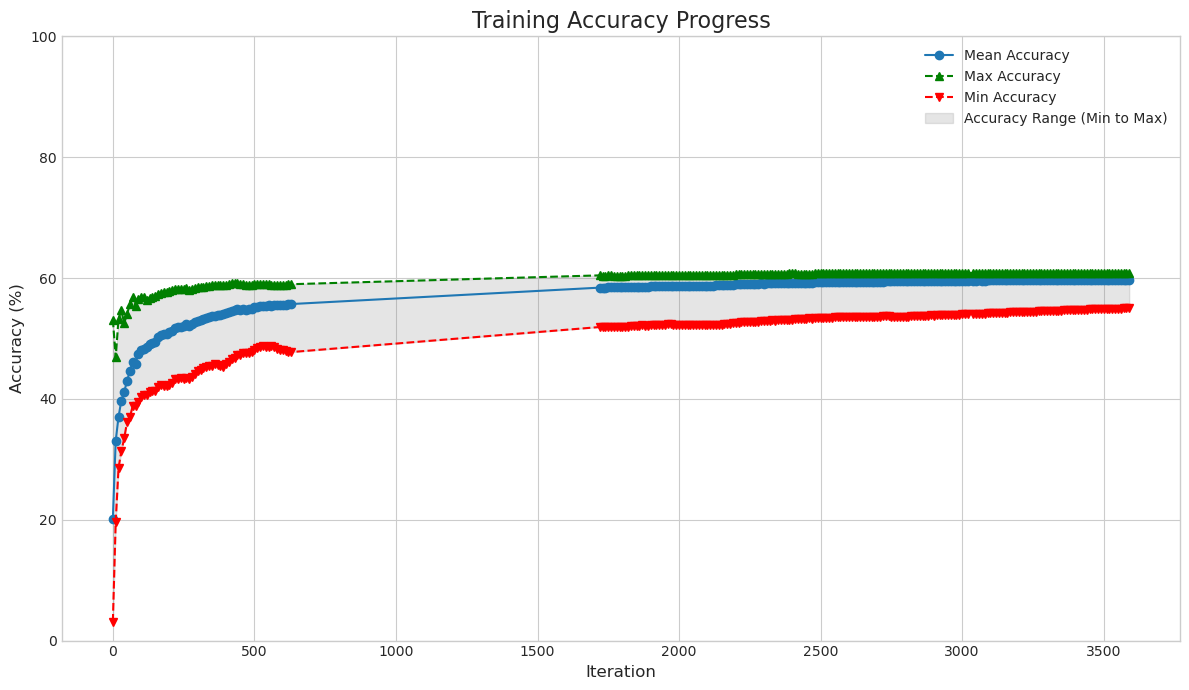

In [26]:
# Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the mean, max, and min accuracy lines
ax.plot(iterations, mean_accuracies, marker='o', linestyle='-', label='Mean Accuracy')
ax.plot(iterations, max_accuracies, marker='^', linestyle='--', color='green', label='Max Accuracy')
ax.plot(iterations, min_accuracies, marker='v', linestyle='--', color='red', label='Min Accuracy')

# Shade the area between the max and min accuracy to show the range
ax.fill_between(
    iterations,
    min_accuracies,
    max_accuracies,
    color='gray',
    alpha=0.2,
    label='Accuracy Range (Min to Max)'
)

# Adding labels, title, and legend
ax.set_title('Training Accuracy Progress', fontsize=16)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 100) # Set y-axis from 0% to 100%

# Display the plot
plt.tight_layout()
plt.show()

# Loss Curves

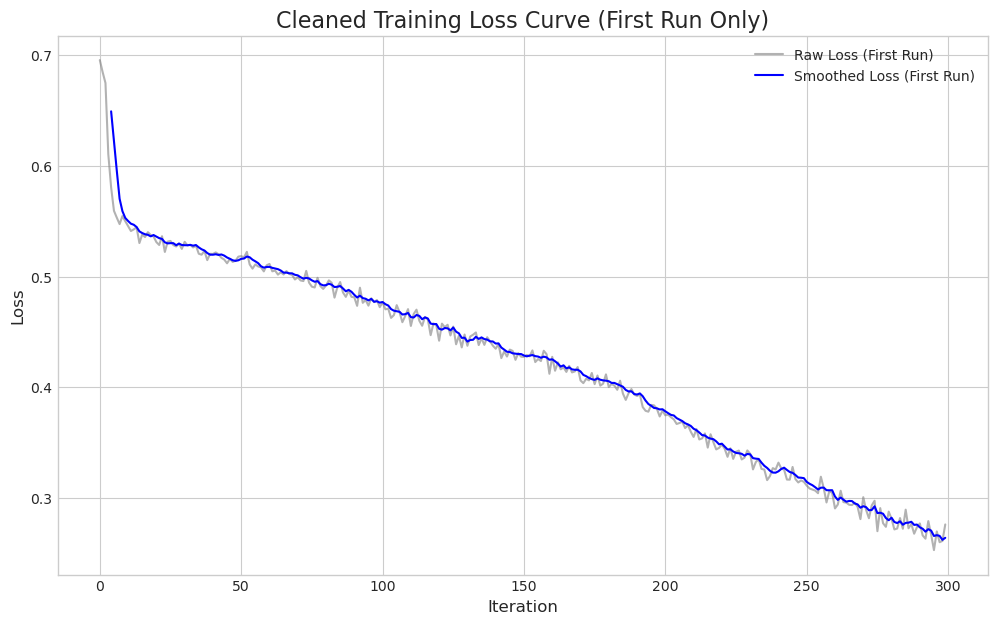

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# --- Step 1: Prepare the data ---
# In a real scenario, you would load your file directly like this:
df = pd.read_csv('checkpoints/anneal/64.8.vitg16-384px-64f/log_r3.csv')

# Use io.StringIO to read the string data as a file
# df = pd.read_csv(io.StringIO(csv_data))


# --- Step 2: Clean the data ---
# Remove the extra header rows where the 'epoch' column contains 'epoch'
df = df[df['epoch'] != 'epoch'].copy()
df['itr'] = pd.to_numeric(df['itr'])
df['loss'] = pd.to_numeric(df['loss'])

# Find the starting indices of all runs by looking for where itr is 0
run_start_indices = df[df['itr'] == 0].index

df_first_run = pd.DataFrame() # Create an empty dataframe to hold the result

# Check if any runs were found
if len(run_start_indices) > 0:
    first_run_start_index = run_start_indices[0]

    # If there is more than one run, the first run ends before the second one starts
    if len(run_start_indices) > 1:
        second_run_start_index = run_start_indices[1]
        df_first_run = df.loc[first_run_start_index : second_run_start_index - 1].reset_index(drop=True)
    # Otherwise, the first run is the only run in the file
    else:
        df_first_run = df.loc[first_run_start_index:].reset_index(drop=True)

    # Calculate a smoothed loss for the isolated run
    df_first_run['loss_smoothed'] = df_first_run['loss'].rolling(window=5).mean()
else:
    print("No valid training run data found.")


# --- Step 3: Plot the Cleaned Result ---
if not df_first_run.empty:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot the data for only the first run
    ax.plot(df_first_run['itr'], df_first_run['loss'], label='Raw Loss (First Run)', color='gray', alpha=0.6)
    ax.plot(df_first_run['itr'], df_first_run['loss_smoothed'], label='Smoothed Loss (First Run)', color='blue')

    # Set titles and labels
    ax.set_title('Cleaned Training Loss Curve (First Run Only)', fontsize=16)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.legend()
    ax.grid(True)

    plt.show()